Fáza 2 - Predspracovanie údajov

In [24]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, QuantileTransformer, RobustScaler, Normalizer

path = Path("../data/cleaned_data")

observation_df = pd.read_csv(path / "observation.csv")
patient_df = pd.read_csv(path / "patient.csv")
station_df = pd.read_csv(path / "station.csv")

to-do
- нужно взять две другие таблицы привести все их памаметры в нумерицки и соединить их с обзервашон

In [25]:
#тут уже придется использовать не обзервацию, а соединеную тублицу

X = observation_df.drop('oximetry', axis=1)
y = observation_df['oximetry']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(9706, 22) (2427, 22)


C:\Users\eakos\AppData\Local\Temp\ipykernel_4460\1929682415.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\eakos\Рабочий стол\FIIT\IAU\Kosharova_Oliinyk_iau_67\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


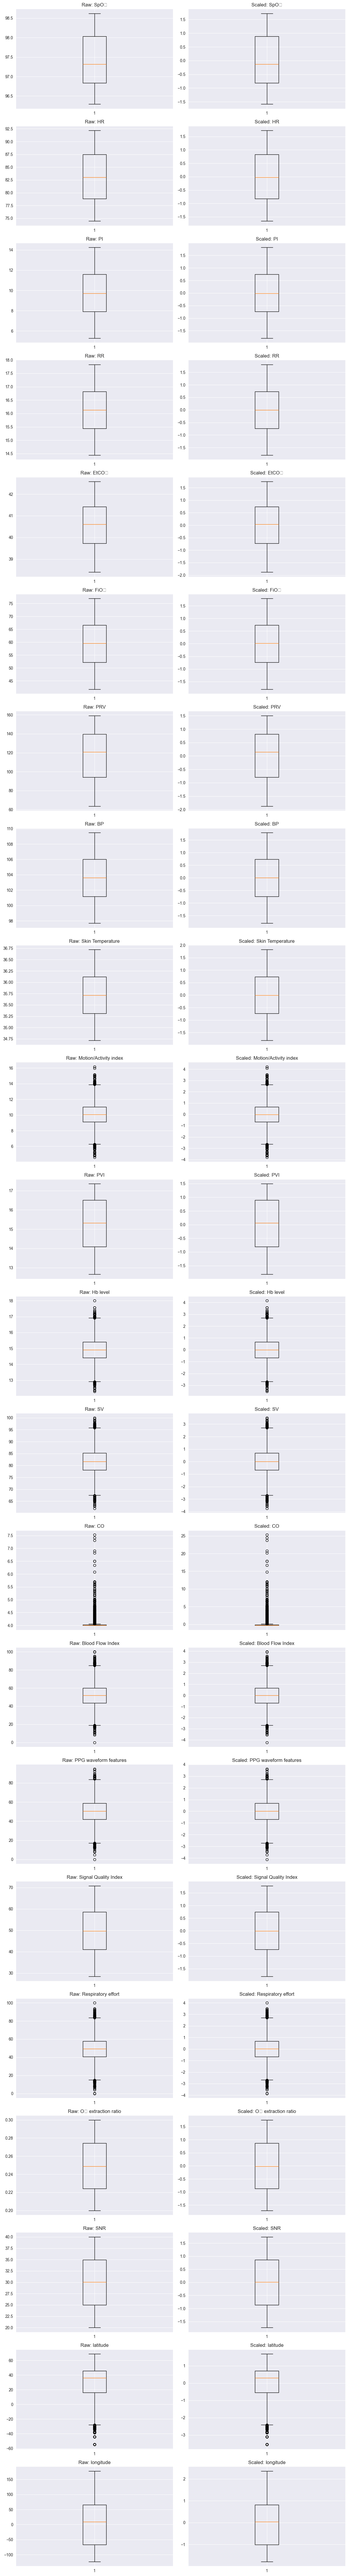

In [27]:
from math import ceil

std_scaler = StandardScaler()
std_scaler.fit(X_train)
X_train_std = std_scaler.transform(X_train)

# Преобразуем обратно в DataFrame, чтобы сохранить имена колонок
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)

n_features = X_train.shape[1]
n_plots = n_features * 2  # для raw и scaled каждого признака
n_cols = 2
n_rows = ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.ravel()  # удобная одномерная индексация

for i, col in enumerate(X_train.columns):

    axes[2 * i].boxplot(X_train[col])
    axes[2 * i].set_title(f"Raw: {col}")

    axes[2 * i + 1].boxplot(X_train_std_df[col])
    axes[2 * i + 1].set_title(f"Scaled: {col}")

# Если остались лишние пустые оси (когда n_plots < n_rows*n_cols), скрыть их
for j in range(2 * n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


C:\Users\eakos\AppData\Local\Temp\ipykernel_4460\2681038860.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\eakos\Рабочий стол\FIIT\IAU\Kosharova_Oliinyk_iau_67\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


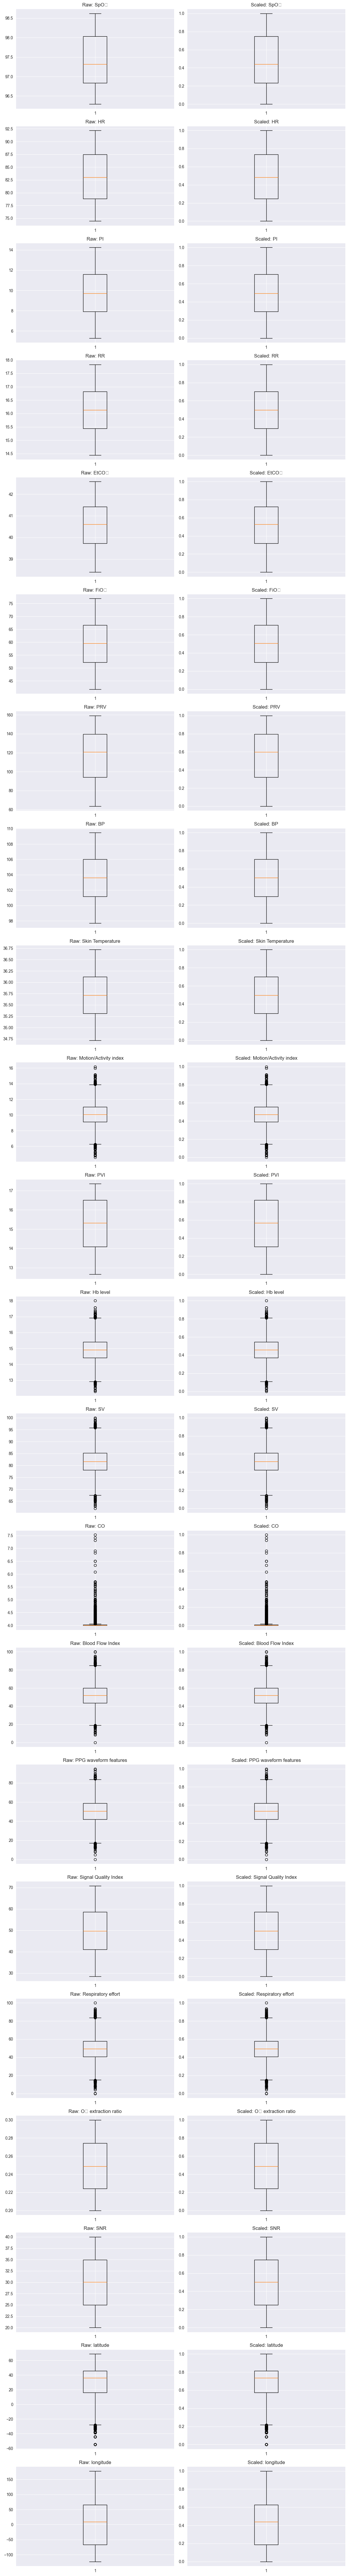

In [37]:
from math import ceil

# ...existing code...

std_scaler = MinMaxScaler()
std_scaler.fit(X_train)
X_train_std = std_scaler.transform(X_train)

# Преобразуем обратно в DataFrame, чтобы сохранить имена колонок
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)

n_features = X_train.shape[1]
n_plots = n_features * 2  # для raw и scaled каждого признака
n_cols = 2
n_rows = ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.ravel()  # удобная одномерная индексация

for i, col in enumerate(X_train.columns):

    axes[2 * i].boxplot(X_train[col])
    axes[2 * i].set_title(f"Raw: {col}")

    axes[2 * i + 1].boxplot(X_train_std_df[col])
    axes[2 * i + 1].set_title(f"Scaled: {col}")

# Если остались лишние пустые оси (когда n_plots < n_rows*n_cols), скрыть их
for j in range(2 * n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


C:\Users\eakos\AppData\Local\Temp\ipykernel_4460\211571835.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\eakos\Рабочий стол\FIIT\IAU\Kosharova_Oliinyk_iau_67\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


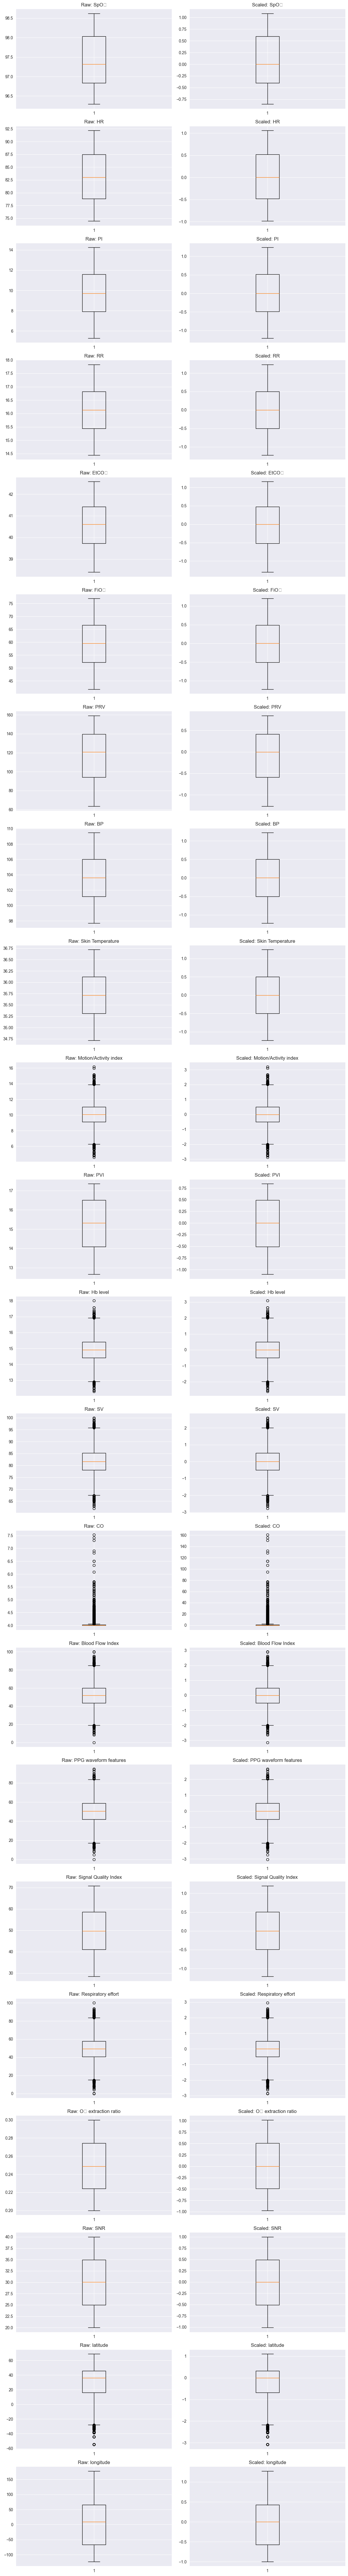

In [30]:
from math import ceil

# ...existing code...

std_scaler = RobustScaler()
std_scaler.fit(X_train)
X_train_std = std_scaler.transform(X_train)

# Преобразуем обратно в DataFrame, чтобы сохранить имена колонок
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)

n_features = X_train.shape[1]
n_plots = n_features * 2  # для raw и scaled каждого признака
n_cols = 2
n_rows = ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.ravel()  # удобная одномерная индексация

for i, col in enumerate(X_train.columns):

    axes[2 * i].boxplot(X_train[col])
    axes[2 * i].set_title(f"Raw: {col}")

    axes[2 * i + 1].boxplot(X_train_std_df[col])
    axes[2 * i + 1].set_title(f"Scaled: {col}")

# Если остались лишние пустые оси (когда n_plots < n_rows*n_cols), скрыть их
for j in range(2 * n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


C:\Users\eakos\AppData\Local\Temp\ipykernel_4460\2995596670.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\eakos\Рабочий стол\FIIT\IAU\Kosharova_Oliinyk_iau_67\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


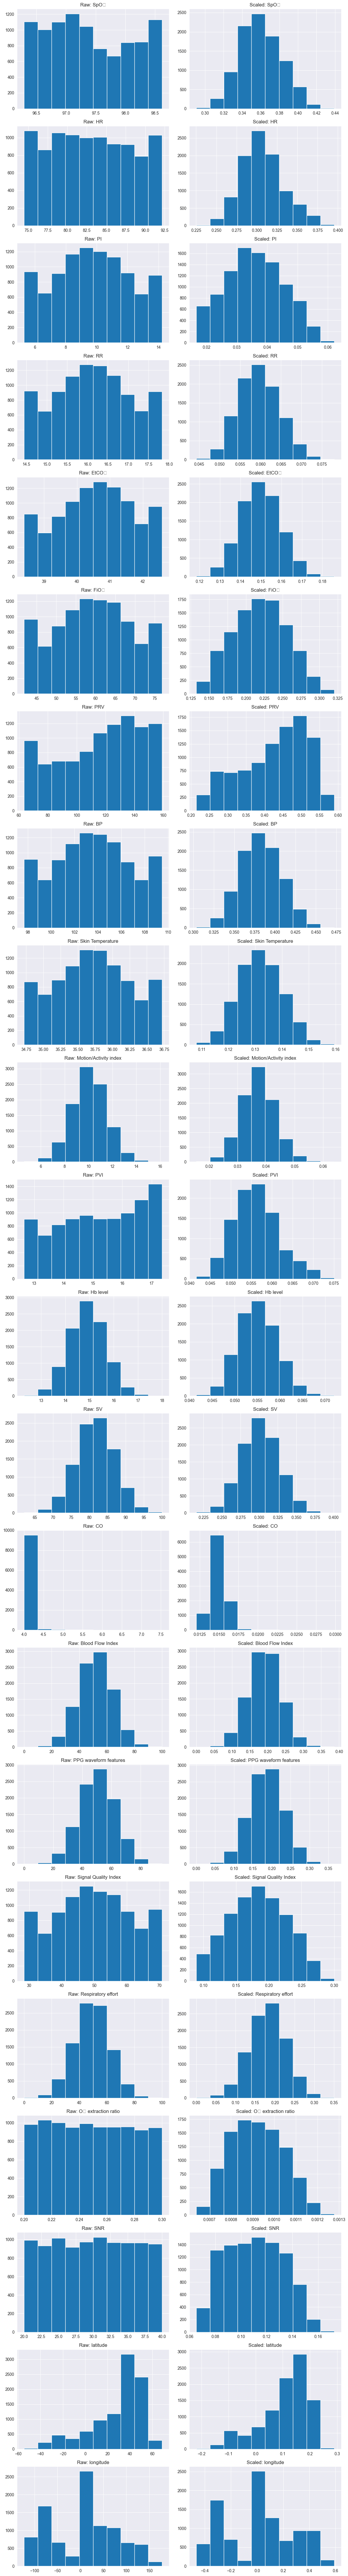

In [32]:
from math import ceil

# ...existing code...

std_scaler = Normalizer()
std_scaler.fit(X_train)
X_train_std = std_scaler.transform(X_train)

# Преобразуем обратно в DataFrame, чтобы сохранить имена колонок
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)

n_features = X_train.shape[1]
n_plots = n_features * 2  # для raw и scaled каждого признака
n_cols = 2
n_rows = ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.ravel()  # удобная одномерная индексация

for i, col in enumerate(X_train.columns):

    axes[2 * i].hist(X_train[col])
    axes[2 * i].set_title(f"Raw: {col}")

    axes[2 * i + 1].hist(X_train_std_df[col])
    axes[2 * i + 1].set_title(f"Scaled: {col}")

# Если остались лишние пустые оси (когда n_plots < n_rows*n_cols), скрыть их
for j in range(2 * n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


C:\Users\eakos\AppData\Local\Temp\ipykernel_4460\3681230708.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\eakos\Рабочий стол\FIIT\IAU\Kosharova_Oliinyk_iau_67\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


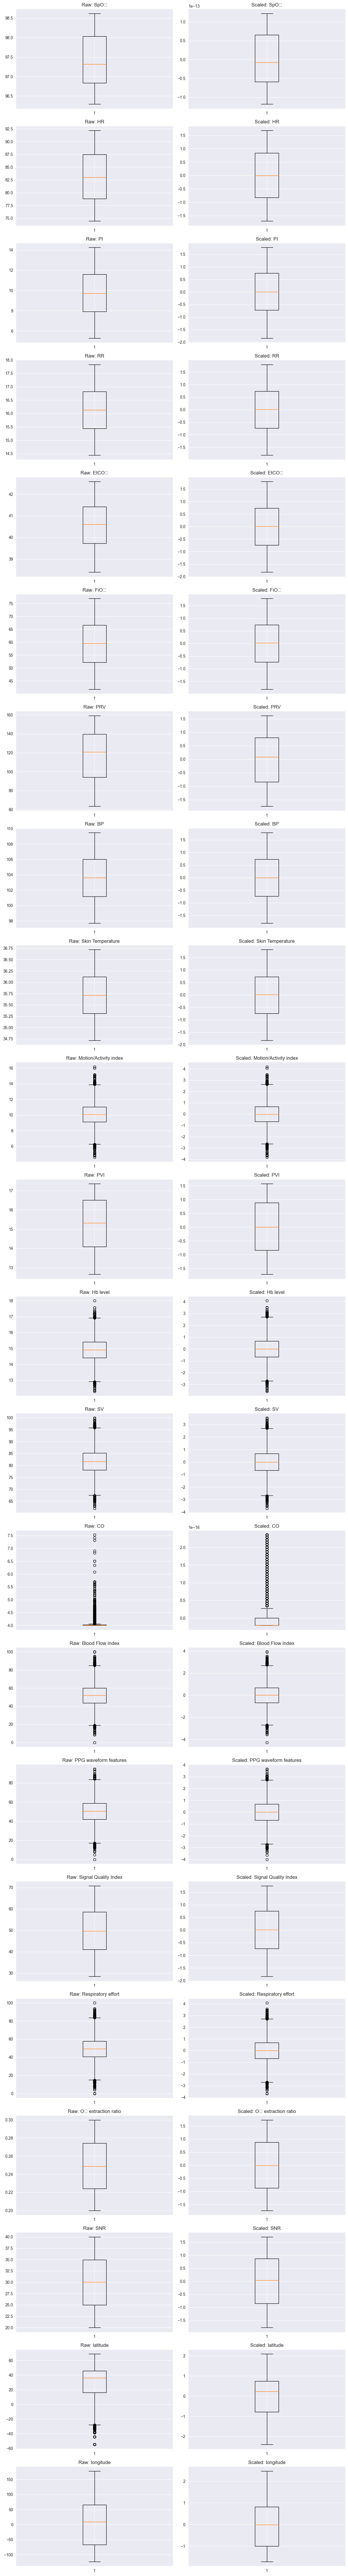

In [36]:
from math import ceil

# ...existing code...

std_scaler = PowerTransformer()
std_scaler.fit(X_train)
X_train_std = std_scaler.transform(X_train)

# Преобразуем обратно в DataFrame, чтобы сохранить имена колонок
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)

n_features = X_train.shape[1]
n_plots = n_features * 2  # для raw и scaled каждого признака
n_cols = 2
n_rows = ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.ravel()  # удобная одномерная индексация

for i, col in enumerate(X_train.columns):

    axes[2 * i].boxplot(X_train[col])
    axes[2 * i].set_title(f"Raw: {col}")

    axes[2 * i + 1].boxplot(X_train_std_df[col])
    axes[2 * i + 1].set_title(f"Scaled: {col}")

# Если остались лишние пустые оси (когда n_plots < n_rows*n_cols), скрыть их
for j in range(2 * n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
